## The dataset is obtained from Kaggle.
[
Most Streamed Spotify Songs 2023 ](https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv('spotify_data.csv')

In [ ]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

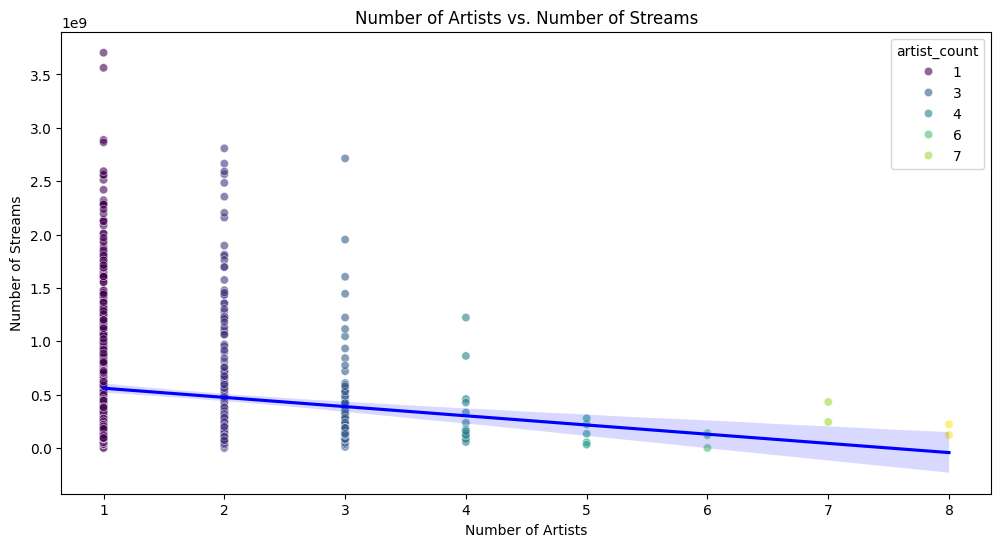

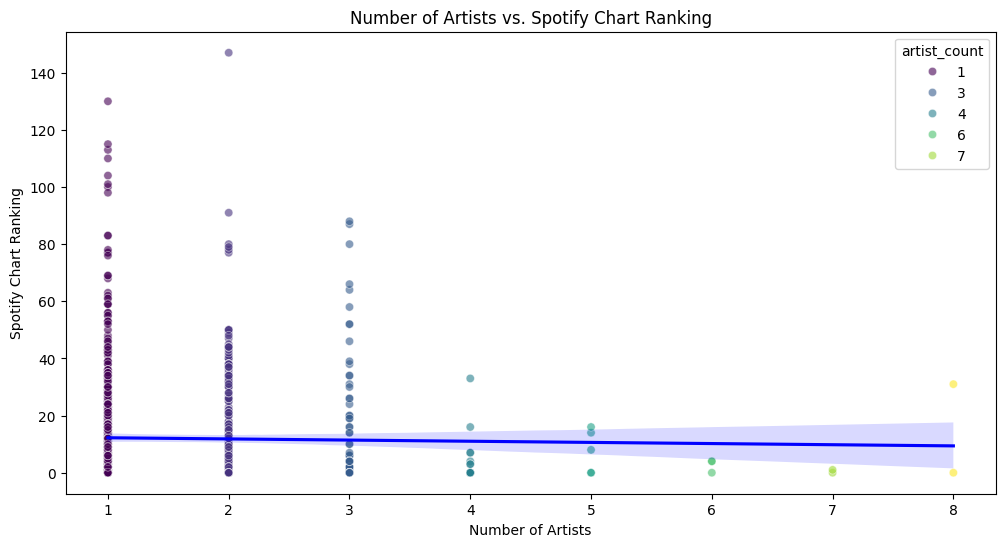

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='artist_count', y='streams', hue='artist_count', palette='viridis', alpha=0.6)
sns.regplot(data=df, x='artist_count', y='streams', scatter=False, color='blue')
plt.title('Number of Artists vs. Number of Streams')
plt.xlabel('Number of Artists')
plt.ylabel('Number of Streams')
plt.show()

# Scatter plot of number of artists vs. chart rankings
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='artist_count', y='in_spotify_charts', hue='artist_count', palette='viridis', alpha=0.6)
sns.regplot(data=df, x='artist_count', y='in_spotify_charts', scatter=False, color='blue')
plt.title('Number of Artists vs. Spotify Chart Ranking')
plt.xlabel('Number of Artists')
plt.ylabel('Spotify Chart Ranking')
plt.show()

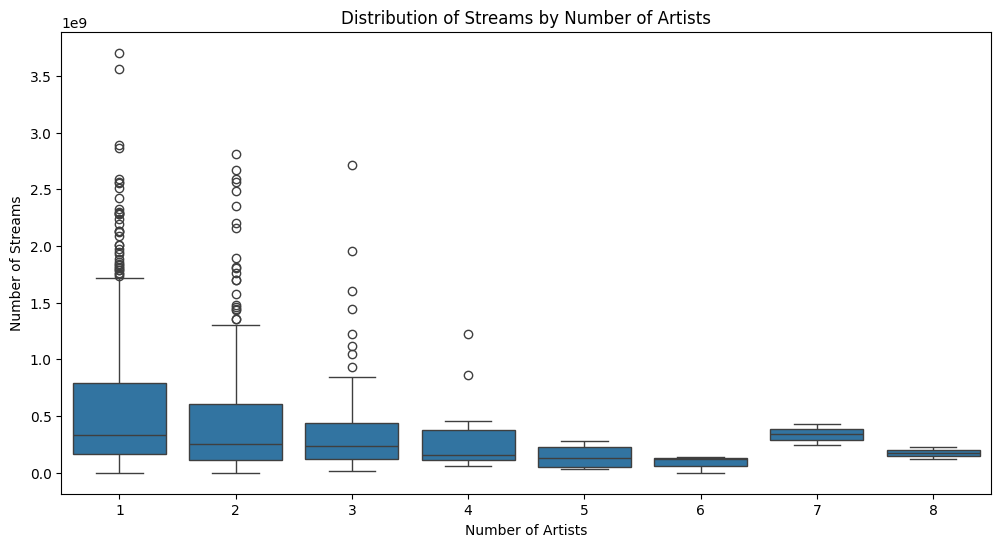

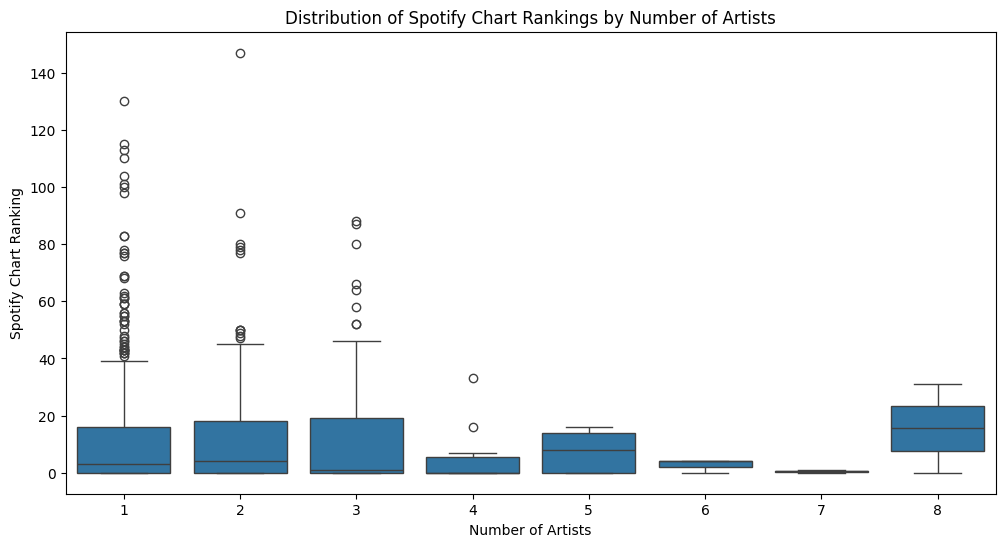

In [ ]:

# Box plot for streams by number of artists
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='artist_count', y='streams')
plt.title('Distribution of Streams by Number of Artists')
plt.xlabel('Number of Artists')
plt.ylabel('Number of Streams')
plt.show()

# Box plot for chart rankings by number of artists
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='artist_count', y='in_spotify_charts')
plt.title('Distribution of Spotify Chart Rankings by Number of Artists')
plt.xlabel('Number of Artists')
plt.ylabel('Spotify Chart Ranking')
plt.show()

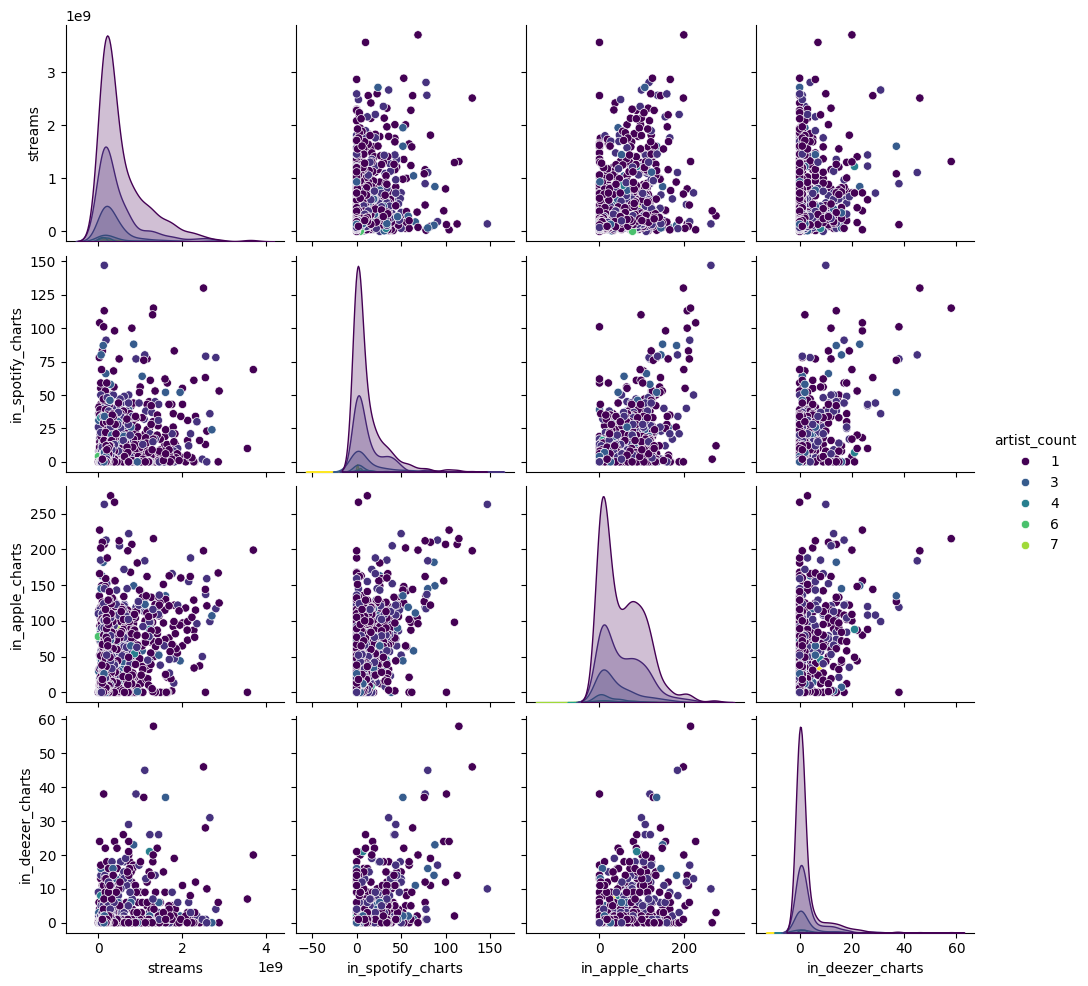

In [ ]:
df_pair = df[['artist_count', 'streams', 'in_spotify_charts', 'in_apple_charts', 'in_deezer_charts']].copy()

# Pair plot to explore relationships
sns.pairplot(df_pair, hue='artist_count', palette='viridis')
plt.show()

## Word Cloud of Artists Who Collaborate the Most

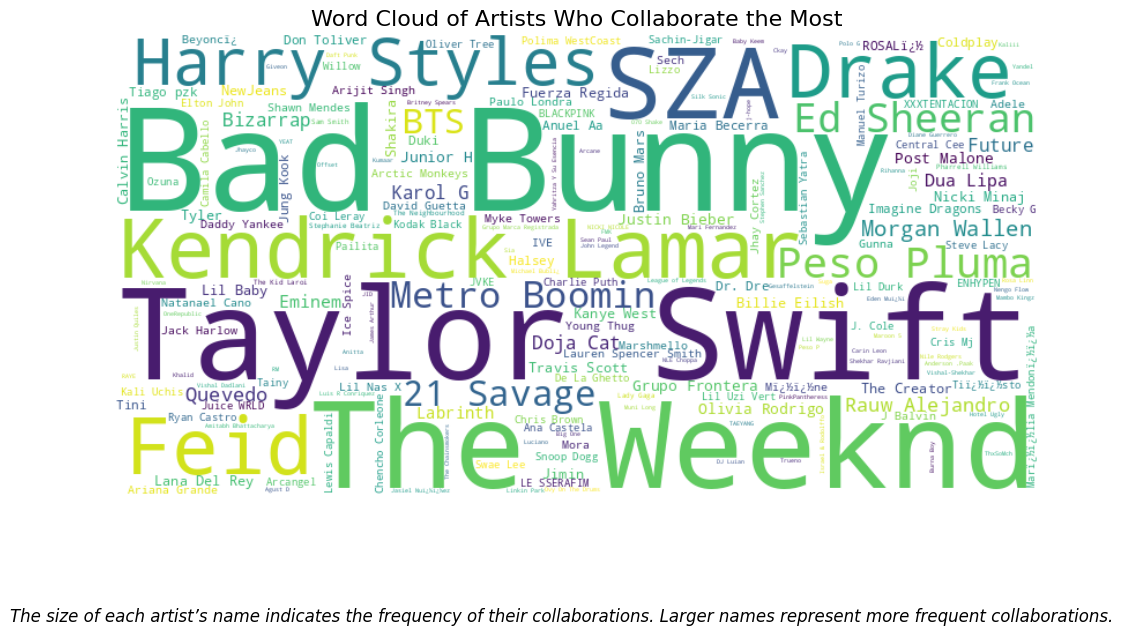

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Count the number of collaborations for each artist
artist_counts = df['artist(s)_name'].apply(lambda x: x.split(', ')).explode().value_counts()

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(artist_counts)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Artists Who Collaborate the Most', fontsize=16)
plt.figtext(0.5, -0.1, 'The size of each artist’s name indicates the frequency of their collaborations. Larger names represent more frequent collaborations.',
            ha='center', fontsize=12, style='italic')
plt.show()

## Monthly Track Releases and Average Streams

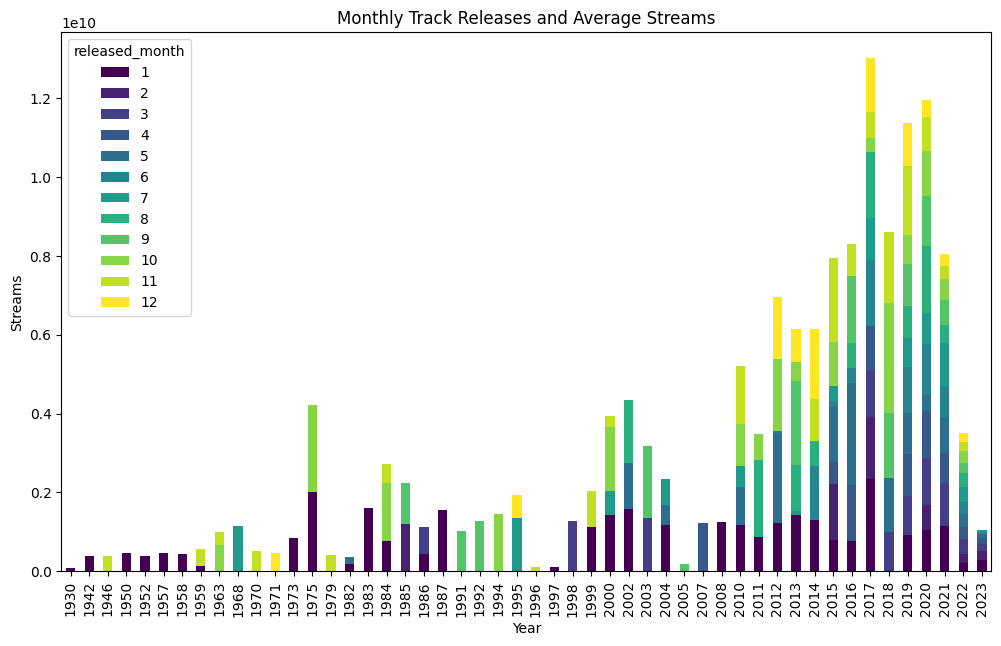

In [ ]:
# Prepare data
stacked_data = df.groupby(['released_year', 'released_month']).agg({
    'track_name': 'count',
    'streams': 'mean'
}).unstack().fillna(0)

stacked_data['streams'].plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Monthly Track Releases and Average Streams')
plt.xlabel('Year')
plt.ylabel('Streams')
plt.show()

## Top 10 Artists with Positive/Energetic Songs

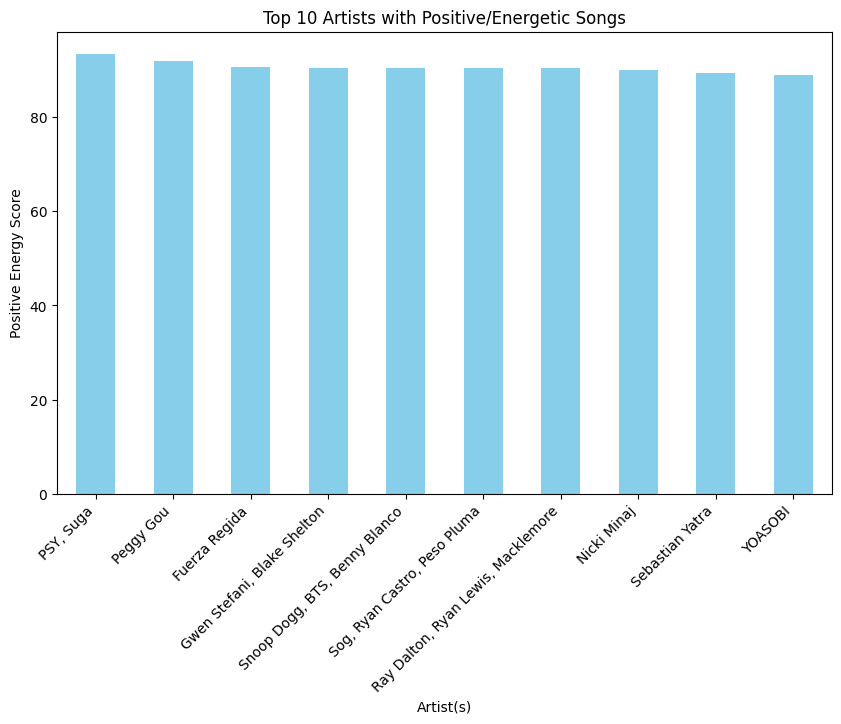

In [ ]:

# Assuming df is your DataFrame
# Filter songs with high positivity (valence) and energy
positive_energetic_songs = df[(df['valence_%'] > 50) & (df['energy_%'] > 50)]

# Group by artist(s)_name and calculate average valence and energy
artist_avg = positive_energetic_songs.groupby('artist(s)_name')[['valence_%', 'energy_%']].mean()

# Combine average valence and energy into a single score (optional)
artist_avg['positive_energy_score'] = (artist_avg['valence_%'] + artist_avg['energy_%']) / 2

# Sort artists by the score and select the top 10
top_artists = artist_avg.sort_values(by='positive_energy_score', ascending=False).head(10)

# Visualization
top_artists['positive_energy_score'].plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Top 10 Artists with Positive/Energetic Songs')
plt.xlabel('Artist(s)')
plt.ylabel('Positive Energy Score')
plt.xticks(rotation=45, ha='right')
plt.show()

## Top 10 Artists based on genre

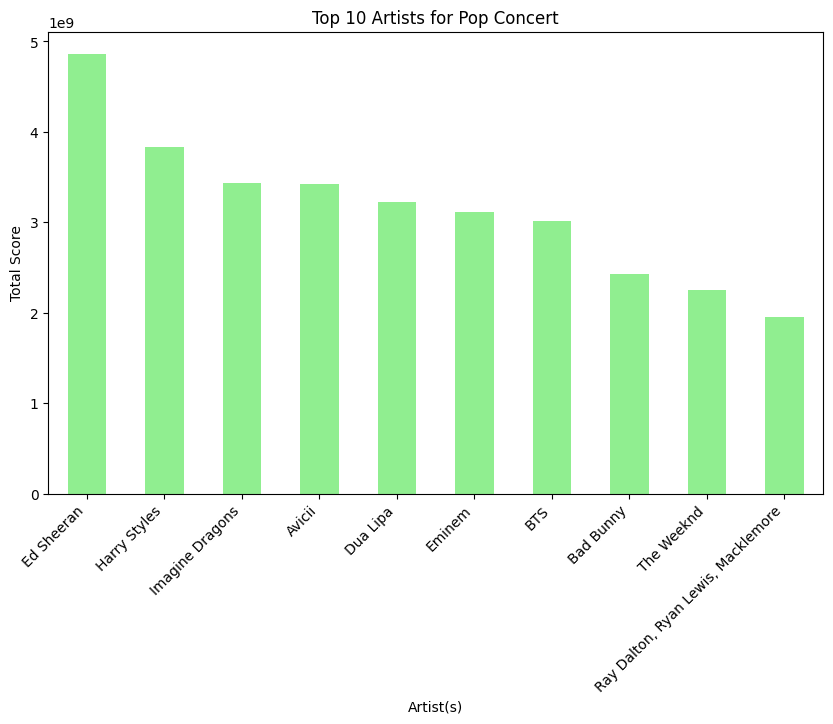

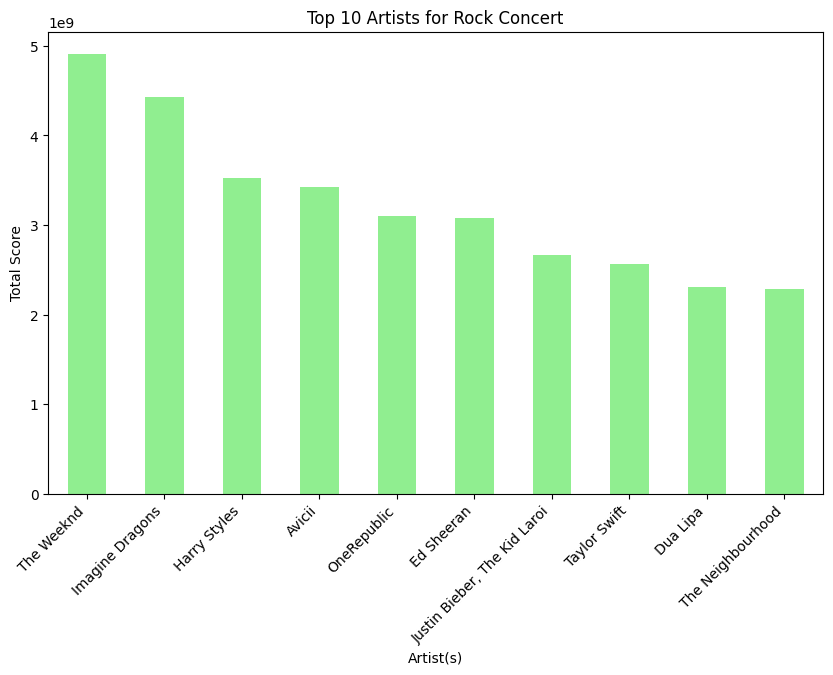

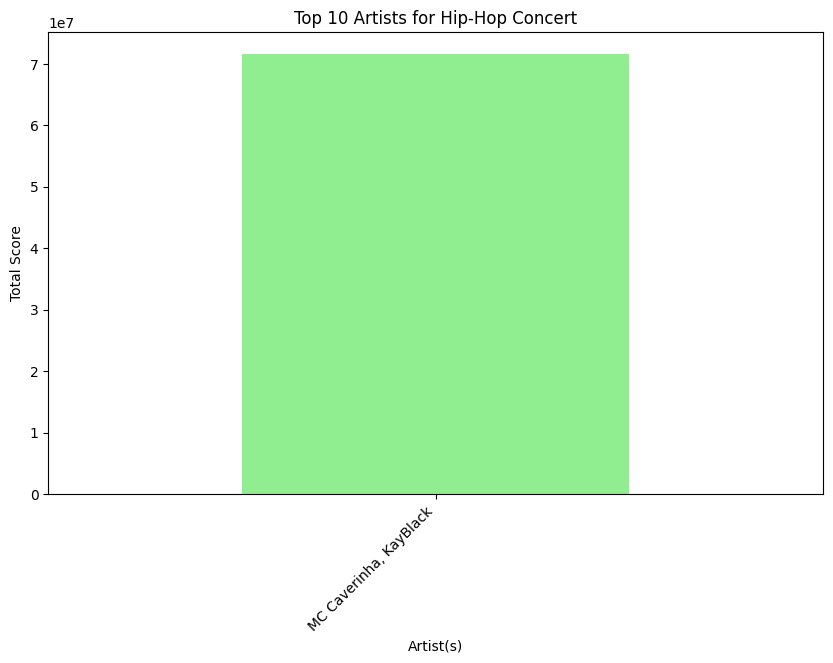

In [ ]:

def select_top_artists(mood):
    if mood == 'Pop':
        filtered_df = df[(df['valence_%'] > 60) & (df['energy_%'] > 60)]
    elif mood == 'Rock':
        filtered_df = df[(df['energy_%'] > 70) & (df['bpm'] > 120)]
    elif mood == 'Hip-Hop':
        filtered_df = df[(df['speechiness_%'] > 60) & (df['bpm'] > 80)]
    elif mood == 'Classical':
        filtered_df = df[(df['instrumentalness_%'] > 70) & (df['energy_%'] < 40)]
    elif mood == 'Folk':
        filtered_df = df[(df['valence_%'] > 50) & (df['energy_%'] < 50)]

    # Aggregate by artist
    artist_scores = filtered_df.groupby('artist(s)_name').agg({
        'streams': 'sum',
        'in_spotify_playlists': 'sum',
        'in_spotify_charts': 'sum',
        'in_apple_playlists': 'sum',
        'in_apple_charts': 'sum',
        'in_deezer_playlists': 'sum',
        'in_deezer_charts': 'sum',
        'in_shazam_charts': 'sum'
    })

    # Calculate a combined score (simple sum for now)
    artist_scores['total_score'] = artist_scores.sum(axis=1)

    # Sort and select the top 10
    top_artists = artist_scores.sort_values(by='total_score', ascending=False).head(10)

    # Visualization
    top_artists['total_score'].plot(kind='bar', color='lightgreen', figsize=(10, 6))
    plt.title(f'Top 10 Artists for {mood} Concert')
    plt.xlabel('Artist(s)')
    plt.ylabel('Total Score')
    plt.xticks(rotation=45, ha='right')
    plt.show()

    return top_artists

# Example usage for Pop mood
select_top_artists('Pop')
rock_artists = select_top_artists('Rock')
hiphop_artists = select_top_artists('Hip-Hop')